In [1]:
import numpy as np
import rebound as rb
from matplotlib import pyplot as plt
import sympy as sp
import celmech as cm

from celmech.disturbing_function import get_fg_coefficients

from celmech.poisson_series import PoissonSeries,PSTerm

# get ttv posteriors

In [2]:
from resonantstate.data_download  import get_metadata_observations, download_observations_samples
from resonantstate.analyse_samples import *

from corner import hist2d

In [3]:
df_all_obs = get_metadata_observations()
target = "TOI-1136"
df_selected = df_all_obs[df_all_obs["star_name"].isin([target])]

#download_destination_path = "downloaded_observtions_samples/"
download_destination_path = None
df_list = download_observations_samples(df_selected, download_destination_path)

for k,v in df_list[0].items():
    if k == "samples":
        print(f"{k}:\t...")
    else:
        print(f"{k}:\t{v}")
df = df_list[0]['samples']
df.head(3)

samples_name:	TOI-1136_0
planets_list:	['TOI-1136 b', 'TOI-1136 c', 'TOI-1136 d', 'TOI-1136 e', 'TOI-1136 f', 'TOI-1136 g']
samples:	...
readme:	The mass priors are set between 0 and 5e-4 M_planet_mstar, the eccentricity  priors are set between 0 and 0.4. Stellar radius, mass, and planetary radius ratio set to literature values as in 2023AJ....165...33D 


additional_info:	None
author_name:	Dai
star_name:	TOI-1136
analysis_id:	0
contact_email:	fdai@hawaii.edu
default:	1
robustness:	[-1, -1, -1, -1, -1, -1]
initial_condition_date_BJD:	2458680.0
nb_planets:	6
gaia_id:	DR2 1677343097418015488
mass_prior:	uniform
eccentricity_prior:	uniform
transit_definition:	z+
methods:	TTV
instruments:	TESS
bibtex:	2023AJ....165...33D
code_used:	2023AJ....165...33D
other_remarks:	


,sample_index,mean_longitude_deg_0,period_days_0,k_0,h_0,inclination_deg_0,longitude_of_ascending_node_deg_0,mass_planet_star_ratio_0,radius_planet_star_ratio_0,mean_longitude_deg_1,...,mean_longitude_deg_5,period_days_5,k_5,h_5,inclination_deg_5,longitude_of_ascending_node_deg_5,mass_planet_star_ratio_5,radius_planet_star_ratio_5,mass_star_m_sun,radius_star_r_sun
0,0.0,73.566216,4.171908,0.059807,0.065846,90.0,7.111887e-31,0.000009,0.018,-50.816359,...,158.900044,39.546193,0.003208,-0.044256,90.0,1.340163e-30,0.000009,0.0239,1.022,0.968
1,1.0,71.137696,4.172276,0.090628,0.140140,90.0,1.436850e-30,0.000004,0.018,-53.274310,...,158.139950,39.544979,0.009702,-0.046777,90.0,-6.701938e-31,0.000008,0.0239,1.022,0.968
2,2.0,77.730327,4.172739,0.017910,0.007730,90.0,-3.542283e-31,0.000015,0.018,-46.024168,...,153.844591,39.547367,0.044493,-0.092152,90.0,2.018845e-30,0.000005,0.0239,1.022,0.968


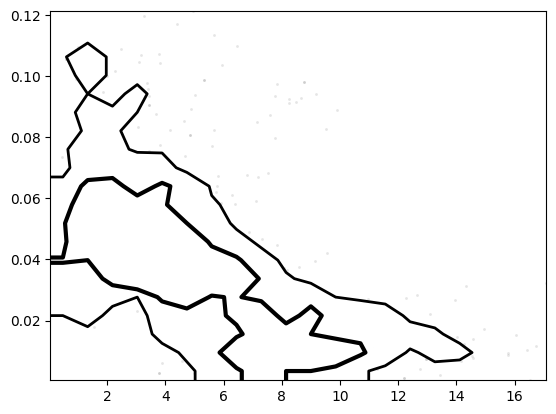

In [4]:
for i in range(df_list[0]['nb_planets']):
    df[f'z_{i}'] = df[f'k_{i}'] + 1j * df[f'h_{i}'] 

for i in range(df_list[0]['nb_planets']-1):
    pratio = df[f'period_days_{i+1}']/df[f'period_days_{i}']
    jres = int(np.round(1+1/(pratio.median()-1)))
    Delta = (jres-1)*pratio/jres - 1
    f,g = get_fg_coefficients(jres,1)
    denom = np.sqrt(f*f+g*g)
    df[f'Z_{i}_{i+1}'] = (f * df[f'z_{i}'] + df[f'z_{i+1}']) / denom

hist2d(
    df['mass_planet_star_ratio_4'].values/3e-6 , 
    np.abs(df['Z_3_4']).values,
    plot_density=False,
    levels=[0.68,0.95],
    contour_kwargs={'linewidths':[2,3]}
)

In [5]:
def row_to_rebound_sim(row,npl):
    DEG2RAD = np.pi / 180
    sim = rb.Simulation()
    sim.units = ('Msun','days','AU')
    Mstar = row['mass_star_m_sun']
    sim.add(m=Mstar)
    for i in range(npl):
        h,k = np.real((row[f'h_{i}'],row[f'k_{i}']))
        ecc = np.sqrt(h*h+k*k)
        pomega = np.arctan2(h,k)
        
        sim.add(
            m = row[f'mass_planet_star_ratio_{i}'] * Mstar,
            P = row[f'period_days_{i}'],
            e = ecc,
            inc = row[f'inclination_deg_{i}'] * DEG2RAD,
            l = row[f'mean_longitude_deg_{i}'] * DEG2RAD,
            pomega = pomega,
            Omega = row[f'longitude_of_ascending_node_deg_{i}'] * DEG2RAD
        )
    sim.move_to_com()

    return sim
    

In [6]:
sim = row_to_rebound_sim(df.iloc[0],df_list[0]['nb_planets'])
sim.integrator = 'whfast'
sim.ri_whfast.safe_mode = 0
sim.dt = sim.particles[1].P / 25.
Tfin = 5e4 * sim.particles[1].P
sim.save_to_file("tmp.sa",interval=Tfin / 256,delete_file=True)
sim.integrate(Tfin)

# dynamics

In [7]:
import requests
import pandas as pd
from io import StringIO


from resonant_chains import get_chain_rebound_sim
def get_chain_hpert(resonances, max_order,max_order_dl = 1):
    sim = get_chain_rebound_sim(resonances,masses)
    pvars = cm.Poincare.from_Simulation(sim)
    pham = cm.PoincareHamiltonian(pvars)
    periods = []
    period = 1
    periods.append(period)
    for j,k in resonances:
        period *= j/sp.S(j-k)
        periods.append(period)
    hpert_series_terms = []

    ei_order = lambda k,nu: np.sum(np.abs(k[2:])) + 2*np.sum(nu)
    for i1,p1 in enumerate(periods):
        for i2,p2 in zip(range(i1+1,len(periods)),periods[i1+1:]):
            pratio = p2/p1
            p,q = int(sp.numer(pratio)),int(sp.numer(pratio) - sp.denom(pratio))
            resonant_terms = cm.disturbing_function.list_resonance_terms(p,q,max_order = max_order)
            if len(resonant_terms)>0:
                print("adding terms for {}:{} MMR between {} and {}".format(p,p-q,i1+1,i2+1))
            for k,nu in resonant_terms:
                hpert_series_terms += cm.poisson_series.DFTerm_as_PSterms(pham,i1+1,i2+1,k,nu,(0,0))
                if ei_order(k,nu) <= max_order_dl:
                    hpert_series_terms += cm.poisson_series.DFTerm_as_PSterms(pham,i1+1,i2+1,k,nu,(1,0))
                    hpert_series_terms += cm.poisson_series.DFTerm_as_PSterms(pham,i1+1,i2+1,k,nu,(0,1))

    secular_terms = cm.disturbing_function.list_secular_terms(min_order=0,max_order = max_order)
    for k,nu in secular_terms:
        for i1 in range(1,sim.N):
            for i2 in range(i1+1,sim.N):
                hpert_series_terms += cm.poisson_series.DFTerm_as_PSterms(pham,i1,i2,k,nu,(0,0))
                if ei_order(k,nu) <= max_order_dl:
                    hpert_series_terms += cm.poisson_series.DFTerm_as_PSterms(pham,i1,i2,k,nu,(1,0))
                    hpert_series_terms += cm.poisson_series.DFTerm_as_PSterms(pham,i1,i2,k,nu,(0,1))
    return PoissonSeries.from_PSTerms(hpert_series_terms)
from celmech.nbody_simulation_utilities import add_canonical_heliocentric_elements_particle
import rebound as rb
import celmech as cm
def Deltas_to_pvars(Deltas,resonances,masses):
    sim = rb.Simulation()
    sim.add(m=1)
    Period = 1
    add_canonical_heliocentric_elements_particle(masses[0],{'a' : Period**(2/3)},sim)
    for Delta,mass,pq in zip(Deltas,masses[1:],resonances):
        p,q = pq
        Period *= (1+Delta)*p/(p-q)
        add_canonical_heliocentric_elements_particle(mass,{'a' : Period**(2/3)},sim)
    sim.move_to_com()

    return cm.Poincare.from_Simulation(sim)

In [8]:
from resonant_chains import ResonantChainPoissonSeries, newton_solve2

In [9]:
periods = np.array([df[f'period_days_{i}'].median() for i in range(df_list[0]['nb_planets'])])
masses = np.array([df[f'mass_planet_star_ratio_{i}'].median() for i in range(df_list[0]['nb_planets'])])
resonances = [(j,2) if j%2 else (j//2,1) for j in np.round(2+2/(periods[1:]/periods[:-1]-1)).astype(int)]
masses = masses
print(resonances)


[(3, 1), (2, 1), (3, 1), (7, 2), (3, 1)]


In [10]:
from resonant_chains import get_lambda_kvecs_in_df, resonant_chain_variables_transformation_matrix

In [11]:
pvars = Deltas_to_pvars([0 for _ in resonances],resonances,masses)
hpert = get_chain_hpert(resonances,3,1)
rc = ResonantChainPoissonSeries(resonances,masses,hpert,max_order = 3)

adding terms for 3:2 MMR between 1 and 2
adding terms for 3:1 MMR between 1 and 3
adding terms for 2:1 MMR between 2 and 3
adding terms for 3:1 MMR between 2 and 4
adding terms for 3:2 MMR between 3 and 4
adding terms for 7:5 MMR between 4 and 5
adding terms for 3:2 MMR between 5 and 6


In [13]:
rc.Tmtrx[:rc.N_planar,:rc.N_planar]

array([[ 0. ,  0. ,  0. ,  0. ,  1. , -1. ],
       [ 0. ,  0. ,  0. ,  0. , -2. ,  3. ],
       [ 1. , -2. ,  1. ,  0. ,  0. ,  0. ],
       [ 0. ,  1. , -4. ,  3. ,  0. ,  0. ],
       [ 0. ,  0. ,  2. , -5.5,  3.5,  0. ],
       [ 0. ,  0. ,  0. ,  2.5, -5.5,  3. ]])

In [20]:
sim = row_to_rebound_sim(df.iloc[0],df_list[0]['nb_planets'])
pvars = cm.Poincare.from_Simulation(sim)
[p.e for p in pvars.particles[1:]]
L10 = pvars.particles[1].Lambda
phi = rc.Tmtrx[1,:rc.N_planar] @ [p.l for p in pvars.particles[1:]]
z_guess = np.array([(p.kappa + 1j * p.eta)/np.sqrt(2*L10)/2 for p in pvars.particles[1:]]) * np.exp(1j * phi)


gcds = []
factors = []
for res1,res2,row in zip(resonances,resonances[1:],rc.Tmtrx[2:rc.N_planar,:rc.N_planar]):
    j1,k1 = res1
    j2,k2 = res2
    k3br = (k2 * np.array([k1-j1,j1,0]) - k1 * np.array([0,k2-j2,j2]))
    
    print(k3br,np.gcd.reduce(k3br))
    factors.append(np.mean(-k3br/row[row!=0]))
    gcds.append(np.gcd.reduce(k3br))
gcds = np.array(gcds)
factors = np.array(factors)

rvars,_ = rc.pvars_to_real_vars(Deltas_to_pvars([0 for _ in range(masses.size-1)],resonances,masses))

guess = rvars
angles_guess = np.mod(rc.Tmtrx[:sim.N-1,:sim.N-1] @ np.array([p.l for p in sim.particles[1:]]),2*np.pi)[2:2+rc.M]
guess[rc.N_planar:rc.N_planar+rc.M] =  angles_guess
guess[:rc.N_planar] =  np.imag(z_guess)
guess[rc.N_planar+rc.M:2*rc.N_planar+rc.M] =  np.real(z_guess)

rc.dK2 = -np.sum(np.abs(z_guess)**2)
print(rc.dK2)
eqC = newton_solve2(rc.planar_flow_and_jacobian,guess)
f,Df = rc.planar_flow_and_jacobian(eqC)
eigs = np.linalg.eigvals(Df)
np.all(np.isclose(np.real(eigs),0))

[-2  4 -2] 2
[-1  4 -3] 1
[-4 11 -7] 1
[-5 11 -6] 1
-0.00393258643062737


True

In [74]:
dK2 = rc.dK2

# compare n-body

In [ ]:
sim  = rc.real_planar_vars_to_pvars(eqC).to_Simulation()
sim.integrator = 'whfast'
sim.ri_whfast.safe_mode = 0
sim.dt = sim.particles[1].P / 30
Tfin= 2*np.pi*5e5
sim.save_to_file("tmp.sa",interval=Tfin/256,delete_file=True)
sim.integrate(Tfin)

In [36]:
resonances

[(3, 1), (2, 1), (3, 1), (7, 2), (3, 1)]

(0.0, 8565.268949587027)

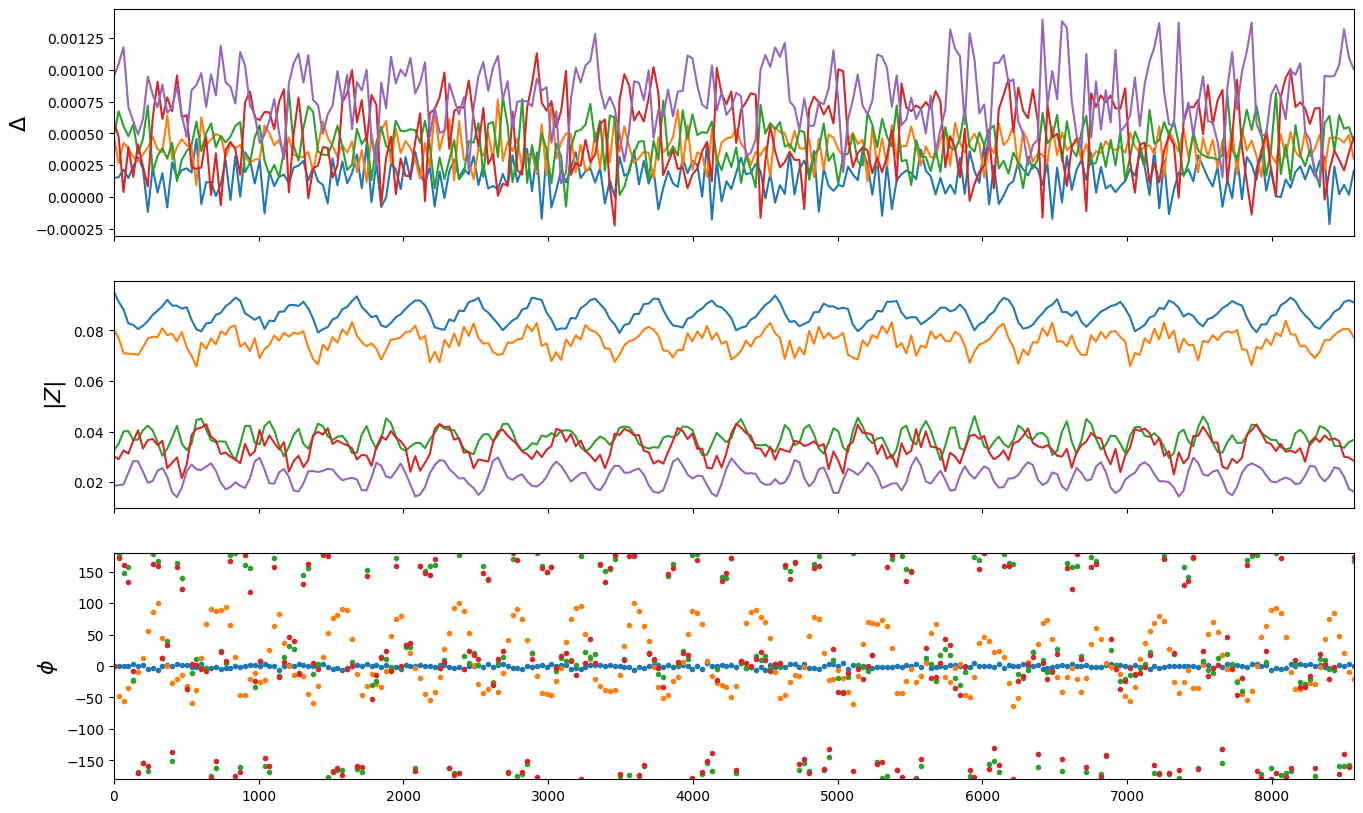

In [35]:
phi_eq_predict = eqC[rc.N_planar:rc.N_planar+rc.M]

fig,ax = plt.subplots(3,1,sharex=True,figsize=(16,10),sharey='row')
# ax_list[0,0].set_title("Without mean-to-osculating correction",fontsize=16)
# ax_list[0,1].set_title("With mean-to-osculating correction",fontsize=16)
finame = "tmp.sa"

results = cm.nbody_simulation_utilities.get_simarchive_integration_results(finame,coordinates='heliocentric')

time_yrs = results['time'] / 365.35
for jk,p1,p2 in zip(resonances,results['P'][:-1],results['P'][1:]):
    j,k = jk
    D = (j-k)*p2/p1/j-1
    l,=ax[0].plot(time_yrs,D)

results['z'] = results['e']*np.exp(1j * results['pomega'])
for jk,z1,z2 in zip(resonances,results['z'][:-1],results['z'][1:]):
    j,k = jk
    f,g = get_fg_coefficients(j,k)
    Z = f*z1 + g*z2
    Z /= np.sqrt(f*f+g*g)
    l,=ax[1].plot(time_yrs,np.abs(Z))
    
mymod = lambda x: np.mod(x+np.pi,2*np.pi)-np.pi
for phi_pred,row in zip(phi_eq_predict,rc.Tmtrx[2:2+rc.M,:rc.N_planar]):
    phi = mymod((row @ results['l'] - phi_pred))
    ax[2].plot(time_yrs,180*phi/np.pi,'.')

ax[0].set_ylabel(r'$\Delta$',fontsize=16)
ax[1].set_ylabel(r'$|Z|$',fontsize=16)
ax[2].set_ylabel(r'$\phi$',fontsize=16)

ax[2].set_ylim(-180,180)
ax[2].set_xlim(0,time_yrs[-1])

In [63]:
asdf = get_lambda_kvecs_in_df(resonances,max_order=2)

In [64]:
asdf.tolist()

[[-2, 3, 0, 0, 0, 0], [-1, 0, 3, 0, 0, 0], [0, -1, 2, 0, 0, 0], [0, -1, 0, 3,  ↪

↪ 0, 0], [0, 0, -2, 3, 0, 0], [0, 0, 0, -5, 7, 0], [0, 0, 0, 0, -2, 3]]

In [71]:
Tmax = np.max(2*np.pi/np.imag(eigs))

In [72]:
from celmech.lie_transformations import FirstOrderGeneratingFunction
print("correcting...")
chi_static = FirstOrderGeneratingFunction(Deltas_to_pvars([0 for _ in range(rc.N_planar-1)],resonances,masses))
Npl = rc.N_planar
for i in range(1,Npl):
    jres,kres = resonances[i-1]
    chi_static.add_zeroth_order_term(i,i+1)    
    print("pair {},{}".format(i,i+1))
    if kres==2:
        jres = jres // 2
        print(f"\t res.: {jres}:{jres-1}")
        chi_static.add_cosine_term(
            [jres,1-jres,-1,0,0,0],
            indexIn=i,
            indexOut=i+1
        )
        chi_static.add_cosine_term(
            [jres,1-jres,0,-1,0,0],
            indexIn=i,
            indexOut=i+1
        )
    for k in range(1,5):
        print(f"\t res.: {jres+k}:{jres+k-1}")

        chi_static.add_cosine_term(
            [jres+k,1-jres-k,-1,0,0,0],
            indexIn=i,
            indexOut=i+1
        )
        print(f"\t res.: {jres-k}:{jres-k-1}")
        chi_static.add_cosine_term(
            [jres-k,1-jres+k,-1,0,0,0],
            indexIn=i,
            indexOut=i+1
        )
        chi_static.add_cosine_term(
            [jres+k,1-jres-k,0,-1,0,0],
            indexIn=i,
            indexOut=i+1
        )
        chi_static.add_cosine_term(
            [jres-k,1-jres+k,0,-1,0,0],
            indexIn=i,
            indexOut=i+1
        )
        
chi_static.mean_to_osculating()

correcting...
pair 1,2
	 res.: 4:3
	 res.: 2:1
	 res.: 5:4
	 res.: 1:0
	 res.: 6:5
	 res.: 0:-1
	 res.: 7:6
	 res.: -1:-2
pair 2,3
	 res.: 3:2
	 res.: 1:0
	 res.: 4:3
	 res.: 0:-1
	 res.: 5:4
	 res.: -1:-2
	 res.: 6:5
	 res.: -2:-3
pair 3,4
	 res.: 4:3
	 res.: 2:1
	 res.: 5:4
	 res.: 1:0
	 res.: 6:5
	 res.: 0:-1
	 res.: 7:6
	 res.: -1:-2
pair 4,5
	 res.: 3:2
	 res.: 4:3
	 res.: 2:1
	 res.: 5:4
	 res.: 1:0
	 res.: 6:5
	 res.: 0:-1
	 res.: 7:6
	 res.: -1:-2
pair 5,6
	 res.: 4:3
	 res.: 2:1
	 res.: 5:4
	 res.: 1:0
	 res.: 6:5
	 res.: 0:-1
	 res.: 7:6
	 res.: -1:-2


In [77]:
from celmech.disturbing_function import get_fg_coefficients
guess = eqC.copy()
dK2vals = dK2 + np.linspace(0.002,-0.01,20) 
eqsC = np.zeros((dK2vals.size,guess.size))
freqs = np.zeros((dK2vals.size,guess.size//2))
lmbdas = np.zeros((dK2vals.size,guess.size//2))
eccs = np.zeros((dK2vals.size,rc.N_planar))
Periods = np.zeros((dK2vals.size,rc.N_planar))
Z = np.zeros((dK2vals.size,rc.N_planar-1))
f_res,g_res = np.transpose([get_fg_coefficients(j,k) for j,k in resonances])

for i,dK2val in enumerate(dK2vals):
    rc.dK2 = dK2val
    guess = newton_solve2(rc.planar_flow_and_jacobian,guess)
    eqsC[i] = guess
    jac = rc.planar_jacobian(guess)
    eigs = np.linalg.eigvals(jac)
    freq = np.sort(np.imag(eigs))
    freqs[i] = freq[freq.size//2:]
    lmbda = np.sort(np.real(eigs))
    lmbdas[i] = lmbda[freq.size//2:]
    pvars = rc.real_planar_vars_to_pvars(guess)
    eccs[i] = [p.e for p in pvars.particles[1:]]
    Periods[i] = [p.P for p in pvars.particles[1:]]
    for l,jk in enumerate(resonances):
        pin = pvars.particles[1+l]
        pout = pvars.particles[2+l]
        zin = pin.e * np.exp(1j * pin.pomega)
        zout = pout.e * np.exp(1j * pout.pomega)
        Z[i,l] = np.abs((f_res[l] * zin + g_res[l] * zout) / np.sqrt(f_res[l] ** 2 + g_res[l] ** 2))

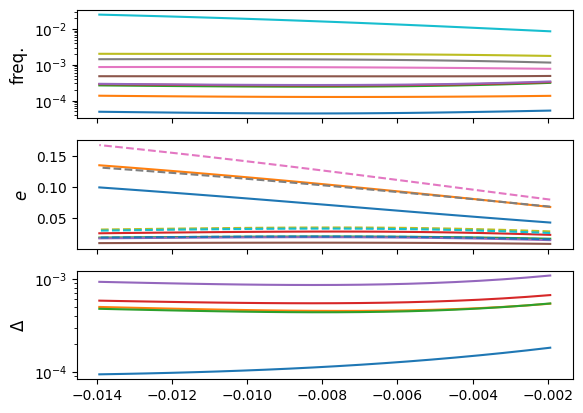

In [78]:
fig,ax = plt.subplots(3,1,sharex=True)
ax[0].plot(dK2vals,freqs)
ax[1].plot(dK2vals,eccs)
ax[1].plot(dK2vals,Z,ls='--')
Deltas = np.array([(jk[0]-jk[1])*p2/p1/jk[0]-1 for p2,p1,jk in zip(Periods.T[1:],Periods.T[:-1],resonances)]).T

ax[2].plot(dK2vals,Deltas)
ax[0].set_ylabel('freq.',fontsize=12)
ax[1].set_ylabel(r"$e$",fontsize=12)
ax[2].set_ylabel(r"$\Delta$",fontsize=12)
ax[2].set_yscale('log')
ax[0].set_yscale('log')

# compare simulations

In [79]:
from scipy.interpolate import interp1d


i_eq = 0 #np.argmin(np.abs(dK2vals - interp1d(Z[:,0],dK2vals,fill_value='extrapolate')(0.01)))

eqC = eqsC[i_eq]
dK2i = dK2vals[i_eq]
rc.dK2 = dK2i

pvars = rc.real_planar_vars_to_pvars(eqC)
sim_eq = pvars.to_Simulation()
sim_eq.integrator='whfast'
sim_eq.dt = sim_eq.particles[1].P / 25.
Tfin = 3 * Tmax
sim_eq.save_to_file("toi-1136",interval=Tfin/256,delete_file=True)
print("integrating...")
sim_eq.integrate(Tfin)

#
print("correcting again...")
pvars = rc.real_planar_vars_to_pvars(eqC)
pvars.values = chi_static.mean_to_osculating_state_vector(rc.real_planar_vars_to_pvars(eqC).values)

sim_eq=pvars.to_Simulation()
sim_eq.integrator='whfast'
sim_eq.dt = sim_eq.particles[1].P / 25.

sim_eq.save_to_file("toi-1136_cc",interval=Tfin/256,delete_file=True)
print("integrating...")
sim_eq.integrate(Tfin)


integrating...
correcting again...
integrating...


In [80]:
rc.Tmtrx[2:2+rc.M,:rc.N_planar]

array([[ 1. , -2. ,  1. ,  0. ,  0. ,  0. ],
       [ 0. ,  1. , -4. ,  3. ,  0. ,  0. ],
       [ 0. ,  0. ,  2. , -5.5,  3.5,  0. ],
       [ 0. ,  0. ,  0. ,  2.5, -5.5,  3. ]])

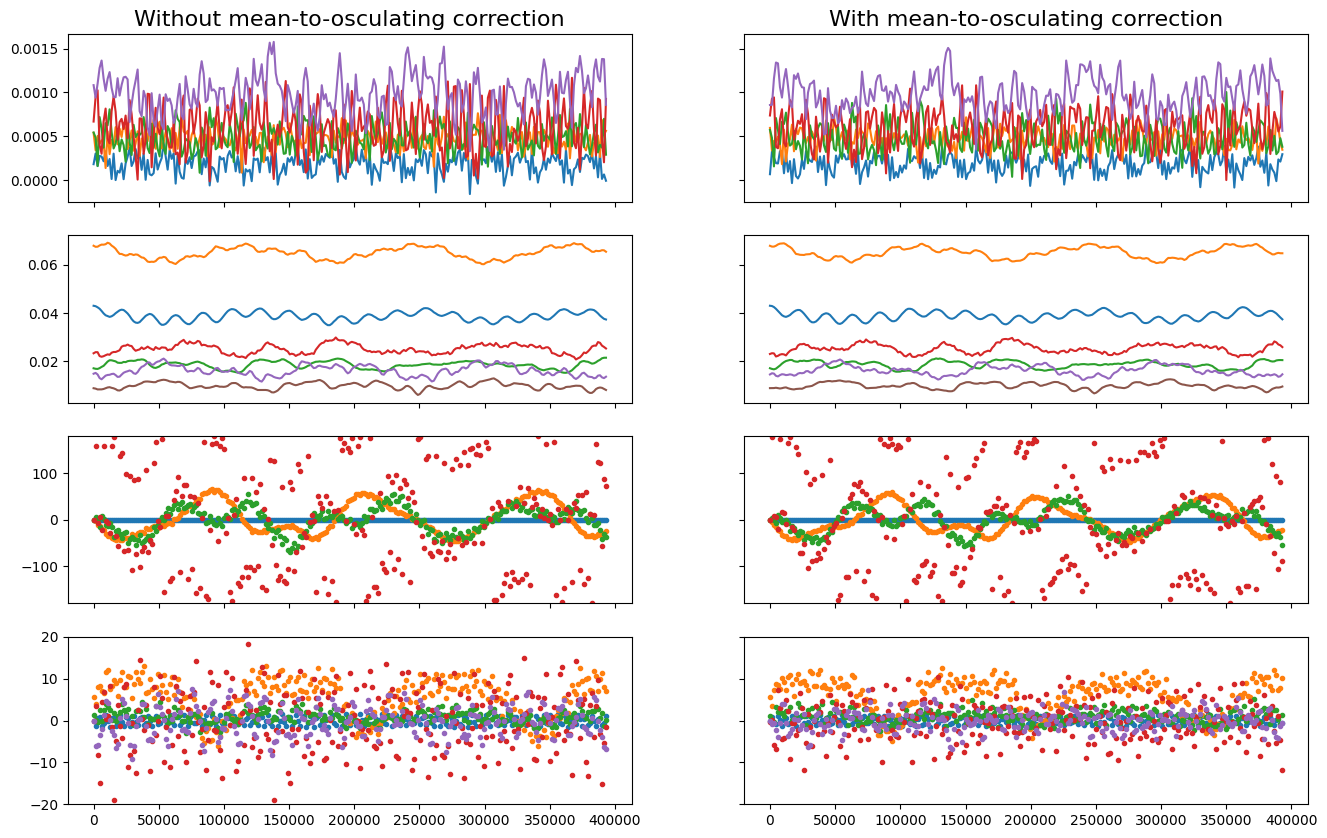

In [88]:
fig,ax_list = plt.subplots(4,2,sharex=True,figsize=(16,10),sharey='row')
ax_list[0,0].set_title("Without mean-to-osculating correction",fontsize=16)
ax_list[0,1].set_title("With mean-to-osculating correction",fontsize=16)
mymod = lambda x: np.mod(x+np.pi,2*np.pi)-np.pi
for finame,ax in zip(("toi-1136","toi-1136_cc"),ax_list.T):
    results = cm.nbody_simulation_utilities.get_simarchive_integration_results(finame,coordinates='heliocentric')
    results['z'] = results['e']*np.exp(1j*results['pomega'])
    for jk,p1,p2 in zip(resonances,results['P'][:-1],results['P'][1:]):
        j,k = jk
        D = (j-k)*p2/p1/j-1
        ax[0].plot(results['time'],D)
    for ecc in results['e']:
        ax[1].plot(results['time'],ecc)

    for l,row in enumerate(rc.Tmtrx[2:2+rc.M,:rc.N_planar]):
        f = 1 if l<2 else 2
        phi = mymod(l*(row @ results['l'] - (row @ results['l'])[0]))
        ax[2].plot(results['time'],180*phi/np.pi,'.')
    ax[2].set_ylim(-180,180)
    all_theta = []
    for l,jk in enumerate(resonances):
        j,k  = jk
        f,g = get_fg_coefficients(j,k)
        argZ = np.angle(f*results['z'][l]+g*results['z'][l+1])
        theta = mymod(j * results['l'][l+1] + (k-j)*results['l'][l] - k * argZ + np.pi)
        all_theta.append(theta)
        ax[3].plot(results['time'],180*theta/np.pi,'.')
    
    ax[3].set_ylim(-20,20)

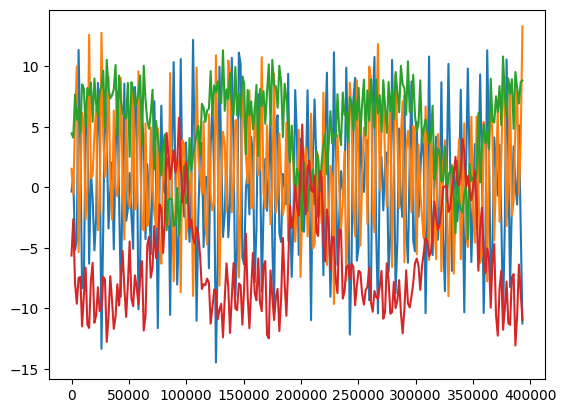

In [95]:
for l in range(1,rc.N_planar-1):
    plt.plot(results['time'],180*(all_theta[-l-1] - all_theta[-l])/np.pi)

In [44]:
for eq,finame,dK2 in zip(eqsC,[f"toi-178_sim_dK2_{v:.5f}" for v in dK2vals],dK2vals):
    pvars = rc.real_planar_vars_to_pvars(eq,dK2 = dK2)
    pvars.values = chi_static.mean_to_osculating_state_vector(pvars.values)
    sim=pvars.to_Simulation()
    sim.save_to_file(finame + ".bin",delete_file=True)

In [45]:
import rebound as rb
from matplotlib import pyplot as plt
import celmech as cm

# dissipative dynamics

In [96]:
from resonant_chains import tau_alphas_to_tau_as

In [97]:
def planar_dissipation_jacobian_symbolic(self,X,p=1):
    #
    # X = y_1,...,y_N,kappa_2,phi_1,...,phi_M,x_1,...,x_N,dK2,Phi_1,...,Phi_M
    #
    # dlna/dt = -1/tau_m - 2 p e^2/tau_e

    Ndim = 2*(self.M+self.N_planar+1)
    Npl = self.N_planar
    tau_e = [1/g for g in sp.symbols("gamma_e(1:{})".format(Npl+1),real=True)]
    rho = self.Lambda0s/self.Lambda0s[0]
    dis_jac = np.zeros((Ndim,Ndim),dtype=object)
    D_gamma_a = np.zeros((Npl,Ndim),dtype=object)

    Tinv_transpose = self.Tmtrx_inv.T

    nu_vec = Tinv_transpose[0,:Npl]
    for i in range(Npl):
        i_x = i+Npl+self.M+1
        D_gamma_a[i,i] = 4 * p * X[i] / tau_e[i] / rho[i]
        D_gamma_a[i,i_x] = 4 * p * X[i_x] / tau_e[i] / rho[i]

    K1_by_L10 = nu_vec @ rho
    D_K1_by_L10 = -0.5 * (rho * nu_vec) @ D_gamma_a

    for i,a_i in enumerate(Tinv_transpose[1:self.M+2,:Npl]):   
        i_P = 2 * Npl + self.M + 1 + i
        dis_jac[i_P] += -0.5 * rho * a_i @ D_gamma_a / K1_by_L10
        dis_jac[i_P] += -1 * (a_i @ rho) * D_K1_by_L10 / (K1_by_L10**2)
    dis_jac *= nu_vec @ rho

    i_dK2 = 2 * Npl + self.M+1
    for i in range(Npl):
        gamma_e = 1/tau_e[i]
        dis_jac[i,i] += -1 * gamma_e
        i_x = i+Npl+self.M+1
        dis_jac[i_x,i_x] += -1 * gamma_e
        # dK2
        dis_jac[i_dK2,i] += 2 * gamma_e * X[i]
        dis_jac[i_dK2,i_x] += 2 * gamma_e * X[i_x]
    return dis_jac

In [99]:
i_kappa2 = rc.N_planar 
i_dK2    = 2 * rc.N_planar + rc.M
rc.dK2 = dK2vals[i_eq]

In [49]:
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

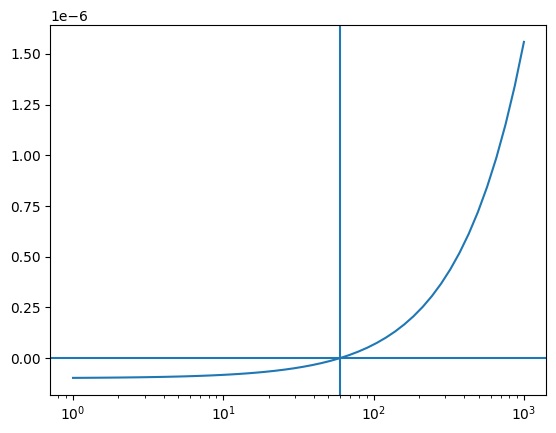

In [105]:
tau_as = np.ones(rc.N_planar) * 1e7
tau_as[0] = np.inf
tau_alphas = 1/(1/tau_as[0]-1/tau_as[1:])
tau_as_new = tau_alphas_to_tau_as(tau_alphas,masses,resonances)

x0 = np.insert(eqsC[i_eq],[-rc.M],[dK2vals[i_eq]])
Kvals=np.geomspace(1,1_000,50)
f_of_K = np.zeros(Kvals.size)
f_of_K_zerop = np.zeros(Kvals.size)
for i,K in enumerate(Kvals):
    tau_es = np.ones(rc.N_planar) * 1e7 / K
    #tau_es[1:] = np.inf
    f_of_K[i] = rc.planar_flow_with_dissipation(x0,tau_es,tau_as,1)[-rc.M-1]
plt.plot(Kvals,f_of_K)
plt.axhline(0)
plt.xscale('log')
Keq_estimate = 10**interp1d(f_of_K,np.log10(Kvals))(0)    
tau_es = np.ones(rc.N_planar) * 1e7 / Keq_estimate
plt.axvline(Keq_estimate)


In [106]:
tau_alphas = 1/(1/tau_as[0]-1/tau_as[1:])
tau_as_new = tau_alphas_to_tau_as(tau_alphas,masses,resonances)
eq_dis = newton_solve2(
    lambda y: rc.planar_flow_and_jacobian_with_dissipation(y,tau_es,tau_as_new,1),
    x0
)
print((x0[i_dK2]-eq_dis[i_dK2])/x0[i_dK2])
j = rc.planar_jacobian_with_dissipation(eq_dis,tau_es,tau_as_new,1)
eig_rates = np.sort(np.real(np.linalg.eigvals(j)))
Tmax=1/np.max(eig_rates)
Tmax



-0.004743293023736262


1373560.5213599482

In [107]:
j_cons = rc.planar_jacobian_with_dissipation(x0,np.inf * tau_es,np.inf * tau_as_new, 1)
vals,vecsT = np.linalg.eig(j_cons)
vecs = vecsT.T
covecs = np.linalg.inv(vecsT)

In [108]:
import numpy as np

def zero_small_values(arr, factor, *, copy=False):
    """
    Zero-out entries that are a given factor smaller (in absolute value)
    than the largest magnitude element in a NumPy array.

    Parameters
    ----------
    arr : np.ndarray
        Input array (any shape, real or complex).
    factor : float
        Threshold factor in (0, 1].  Elements whose absolute value is
        strictly less than ``factor * max(abs(arr))`` are set to zero.
        • factor = 1   ➔ only the maximum-magnitude element is kept  
        • factor ≈ 0  ➔ almost everything is kept
    copy : bool, optional
        If ``True`` return a modified *copy* and leave the original
        unchanged.  If ``False`` (default) the operation is in-place.

    Returns
    -------
    np.ndarray
        The thresholded array (same object as ``arr`` unless ``copy=True``).

    Example
    -------
    >>> x = np.array([1e-3, 2, -0.5, 10])
    >>> zero_small_values(x, 0.1)        # in-place
    >>> x
    array([0.   , 2.   , 0.   , 10.  ])
    """
    if not (0 < factor <= 1):
        raise ValueError("factor must be in the interval (0, 1].")

    target = arr.copy() if copy else arr
    max_abs = np.abs(target).max()          # largest magnitude
    cutoff  = factor * max_abs
    mask    = np.abs(target) < cutoff
    target[mask] = 0
    return target


$\tau_\mathrm{wave} = \frac{M_*}{m_p}\frac{M_*}{\Sigma a_p^2}h^4n_p^{-1}$

In [109]:
chain_sim = get_chain_rebound_sim(resonances,masses)

In [110]:
j_dis_symb = planar_dissipation_jacobian_symbolic(
    rc,
    np.insert(x0,i_kappa2,0)
)
j_dis_symb = np.delete(np.delete(j_dis_symb,i_kappa2,axis=0),i_kappa2,axis=1)

sigma = -1.5
gamma_wave = np.array([p.m * p.a**(2+sigma) * p.n for p in chain_sim.particles[1:]])
gamma_wave /= gamma_wave[0]
gamma_wave

for vec,vec_c,covec,val in zip(vecs[::2],vecs[1::2],covecs[::2],vals[::2]):
    exprn = sp.re(covec@j_dis_symb@vec)
    coeffs = np.array([exprn.coeff(g) for g in sp.symbols("gamma_e(1:{})".format(Npl+1),real=True)],dtype=float)
    zero_small_values(coeffs,1e-3)
    if np.any(coeffs>0):
        
        print("{:.5f}".format(np.imag(val)))
        print(np.array2string(coeffs,precision=3))
        angle_amps = np.real(vec[rc.N_planar:rc.N_planar+rc.M]+vec_c[rc.N_planar:rc.N_planar+rc.M])
        print(np.array2string(angle_amps,precision=3))
        rate_typeI = gamma_wave @ coeffs
        print("{:.5f}".format(rate_typeI))
        print()

0.00861
[ 0.067 -0.125  0.     0.     0.     0.   ]
[-1.897e+00  6.330e-01 -8.691e-03  2.722e-04]
-0.02264

0.00177
[ 0.003  0.019  0.045 -0.061 -0.004  0.   ]
[-0.206  1.294 -1.392  0.586]
0.01971

0.00115
[ 0.01   0.104 -0.007  0.041 -0.028 -0.003]
[ 0.318 -0.576 -1.157  1.492]
0.08641

0.00077
[ 0.006  0.178 -0.038 -0.132  0.019 -0.044]
[-0.384  0.163 -0.117  1.948]
0.06594

0.00049
[-0.018  0.092 -0.011 -0.072 -0.302 -0.194]
[ 0.51  -0.271  0.875  1.66 ]
-0.10768

0.00005
[ 0.031  0.057 -0.051 -0.12  -0.147 -0.048]
[ 0.013 -1.74  -0.631 -0.71 ]
-0.04285

0.00014
[ 0.003  0.007 -0.239 -0.261 -0.152 -0.125]
[ 0.006 -1.14   0.866  1.39 ]
-0.27301



# choose $\tau_e\propto \tau_\mathrm{wave}$

In [114]:
gamma_wave

array([1.        , 0.72062951, 0.52890574, 0.31893073, 0.25429299,
       0.25814433])

In [113]:
x0[i_dK2],eq_dis[i_dK2]

(-0.0019325864306273697, -0.0029376171487468503)

-0.015401026504637151

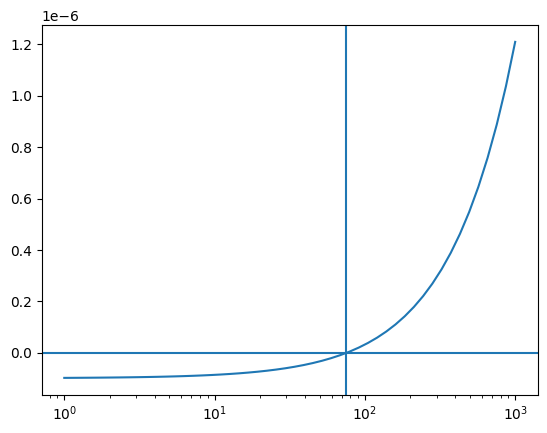

In [116]:
gamma_wave
Ta = 1e7
tau_as = np.ones(rc.N_planar) * Ta
tau_as[0] = np.inf
tau_alphas = 1/(1/tau_as[0]-1/tau_as[1:])
tau_as_new = tau_alphas_to_tau_as(tau_alphas,masses,resonances)

x0 = np.insert(eqsC[i_eq],[-rc.M],[dK2vals[i_eq]])
Kvals=np.geomspace(1,1_000,50)
f_of_K = np.zeros(Kvals.size)
f_of_K_zerop = np.zeros(Kvals.size)
for i,K in enumerate(Kvals):
    tau_es =  Ta / K / gamma_wave
    f_of_K[i] = rc.planar_flow_with_dissipation(x0,tau_es,tau_as,1)[-rc.M-1]
plt.plot(Kvals,f_of_K)
Keq_estimate = 10**interp1d(f_of_K,np.log10(Kvals))(0)    
tau_es = Ta / Keq_estimate / gamma_wave


plt.axvline(Keq_estimate)
plt.axhline(0)
plt.xscale('log')


eq_dis = newton_solve2(
    lambda y: rc.planar_flow_and_jacobian_with_dissipation(y,tau_es,tau_as_new,1),
    x0
)
(x0[i_dK2]-eq_dis[i_dK2])/x0[i_dK2]

In [117]:
j = rc.planar_jacobian_with_dissipation(eq_dis,tau_es,tau_as_new,1)
eig_rates = np.sort(np.real(np.linalg.eigvals(j)))
Tmax=1/np.max(eig_rates)
Tmax

1503961.853819916

In [ ]:
import reboundx as rbx

pv = rc.real_planar_vars_to_pvars(
    np.delete(eq_dis,-rc.M-1),
    dK2=eq_dis[-rc.M-1]
)
sim = pv.to_Simulation()
extras = rbx.Extras(sim)
mod = extras.load_operator('modify_orbits_direct')
mod.params['p']=1
extras.add_operator(mod)
for tau_e,tau_a,p in zip(tau_es,tau_as_new,sim.particles[1:]):
    p.params['tau_e'] = -1*tau_e
    p.params['tau_a'] = -1*tau_a
sim.integrator='whfast'
sim.dt = sim.particles[1].P/30
Tfin = 6 * Tmax

sim.save_to_file("toi-1136_migration.sa",interval = Tfin  / 512,delete_file = True)
sim.integrate(2*Tfin)

In [167]:
results = cm.nbody_simulation_utilities.get_simarchive_integration_results(
    "toi-1136_migration.sa",
    coordinates='heliocentric'
)

(-180.0, 180.0)

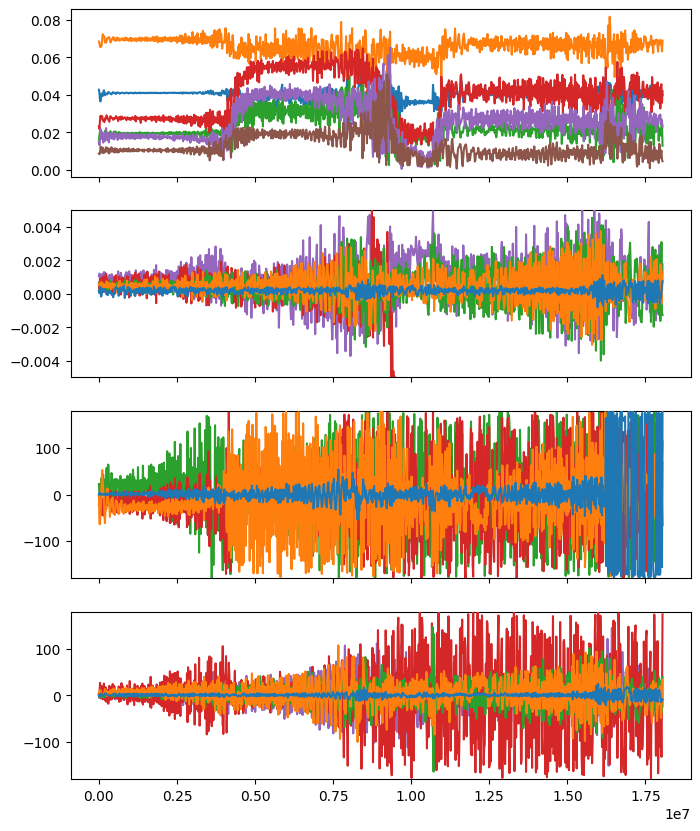

In [177]:
results['z'] = results['e']*np.exp(1j*results['pomega'])
fig,ax = plt.subplots(4,1,sharex=True,figsize=(8,10))

for i in range(rc.N_planar):
    ax[0].plot(results['time'],results['e'][i])

for i in range(rc.N_planar-1):
    P1,P2 = results['P'][i],results['P'][i+1]
    j,k = resonances[i]
    Delta = (j-k)*P2/P1/j - 1
    ax[1].plot(results['time'],Delta,zorder = 99-i)
ax[1].set_ylim(-0.005,0.005)    
for i in range(rc.M-2):
    phi = rc.Tmtrx[2+i,:rc.N_planar]@results['l']
    phi0 = eq_dis[rc.N_planar+i]
    phi = mymod(phi - phi0)
    ax[2].plot(results['time'],180*phi/np.pi,zorder=99-i)
ax[2].plot(results['time'],180*mymod(np.pi + (2*np.array([0,-2,3]) - np.array([-5,7,0])) @ results['l'][-3:])/np.pi,'-',zorder=1)
ax[2].plot(results['time'],180*mymod(np.pi + (2*np.array([-2,3,0]) - np.array([0,-5,7])) @ results['l'][-4:-1])/np.pi,'-',zorder=1)

ax[2].set_ylim(-180,180)
for l,jk in enumerate(resonances):
    j,k  = jk
    f,g = get_fg_coefficients(j,k)
    argZ = np.angle(f*results['z'][l]+g*results['z'][l+1])
    theta = mymod(j * results['l'][l+1] + (k-j)*results['l'][l] - k * argZ + np.pi)
    all_theta.append(theta)
    ax[3].plot(results['time'],180*theta/np.pi,zorder = 99-l)
ax[3].set_ylim(-180,180)